# [실습] 이변량분석(y-범주) : 직원 이직 분석

![](https://menu.moneys.co.kr/moneyweek/thumb/2024/07/30/06/2024073009254442745_4.jpg/dims/optimize/)

- 직원 이직 분석
    - 회사에서 최근 1~2년 사이 이직률이 상승하였다.
    - 여러분은, 직원들이 이직하는데 중요한 요인이 무엇인지 데이터를 기반으로 한 분석을 의뢰 받았다.

# 1.환경준비

## 1.1. 라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import scipy.stats as spst

## 1.2. 데이터 로딩

In [2]:
# 직원 이직 데이터
path = 'data/Attrition.csv'
df = pd.read_csv(path)

df.head()

,Attrition,Age,DistanceFromHome,EmployeeNumber,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,33,7,817,Male,3,Married,11691,No,11,14
1,0,35,18,1412,Male,4,Single,9362,No,11,10
2,0,42,6,1911,Male,1,Married,13348,No,13,18
3,0,46,2,1204,Female,1,Married,17048,No,23,28
4,1,22,4,593,Male,3,Single,3894,No,16,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Attrition          1196 non-null   int64
 1   Age                1196 non-null   int64
 2   DistanceFromHome   1196 non-null   int64
 3   EmployeeNumber     1196 non-null   int64
 4   Gender             1196 non-null   str  
 5   JobSatisfaction    1196 non-null   int64
 6   MaritalStatus      1196 non-null   str  
 7   MonthlyIncome      1196 non-null   int64
 8   OverTime           1196 non-null   str  
 9   PercentSalaryHike  1196 non-null   int64
 10  TotalWorkingYears  1196 non-null   int64
dtypes: int64(8), str(3)
memory usage: 102.9 KB


- 변수설명
    - Attrition	:	이직여부, Yes(1) , No(0) (Target)
    - Age	:	나이
    - DistanceFromHome	:	집-직장 거리(마일)
    - EmployeeNumber	:	사번
    - Gender	:	성별(Male, Female)
    - JobSatisfaction	:	직무 만족도, 다음시트 참조
    - MaritalStatus	:	결혼상태(Married, Single, Divorced)
    - MonthlyIncome	:	월급(달러)
    - OverTime	:	야근여부
    - PercentSalaryHike	:	전년대비 급여인상율(%)
    - TotalWorkingYears	:	총 근무 연수



# 2.범주-->범주

## 2.1. Gender --> Attrition

In [7]:
pd.crosstab(df['Attrition'], df['Gender'])

Gender,Female,Male
Attrition,,
0,403,598
1,66,129


1) 교차표

In [8]:
pd.crosstab(df['Attrition'], df['Gender'], normalize = 'all')

Gender,Female,Male
Attrition,,
0,0.336957,0.50000
1,0.055184,0.10786


2) 시각화

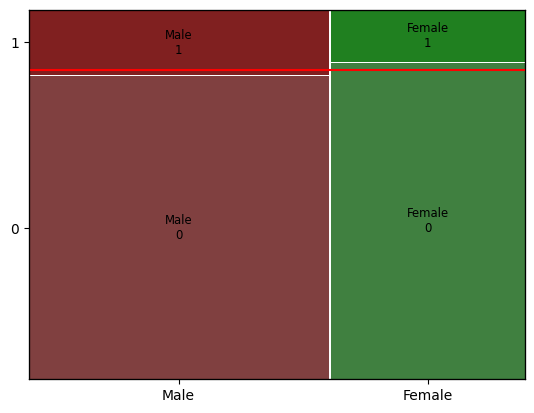

Attrition         0         1
Gender                       
Female     0.859275  0.140725
Male       0.822558  0.177442
------------------------------


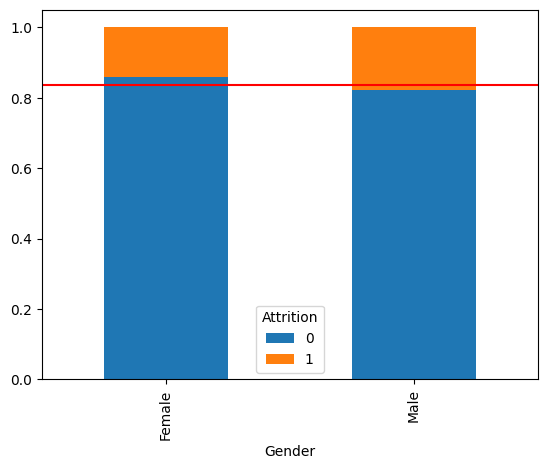

In [10]:
mosaic(df, ['Gender', 'Attrition'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-df['Attrition'].mean(), color='r')    # 전체 
plt.show()
                

temp = pd.crosstab(df['Gender'], df['Attrition'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-df['Attrition'].mean(), color='r')
plt.show()

3) 수치화 : 카이제곱검정

In [12]:
table = pd.crosstab(df['Attrition'], df['Gender'])
display(table)

spst.chi2_contingency(table)

Gender,Female,Male
Attrition,,
0,403,598
1,66,129


Chi2ContingencyResult(statistic=np.float64(2.5537631338119975), pvalue=np.float64(0.1100318964829815), dof=1, expected_freq=array([[392.5326087, 608.4673913],
       [ 76.4673913, 118.5326087]]))

4) 파악된 내용을 기술해 봅시다.

- 귀무가설을 기각하지 못한다
- 통계적으로 유의한 관계가 있다고 보기 어렵다
- 즉, Gender와 Attrition 사이에 유의미한 차이가 있다고 판단하기 어렵다

## 2.2. JobSatisfaction --> Attrition

In [13]:
pd.crosstab(df['Attrition'], df['JobSatisfaction'])

JobSatisfaction,1,2,3,4
Attrition,,,,
0,191,189,295,326
1,52,37,59,47


1) 교차표

In [15]:
pd.crosstab(df['Attrition'], df['JobSatisfaction'], normalize = 'all')

JobSatisfaction,1,2,3,4
Attrition,,,,
0,0.159699,0.158027,0.246656,0.272575
1,0.043478,0.030936,0.049331,0.039298


2) 시각화

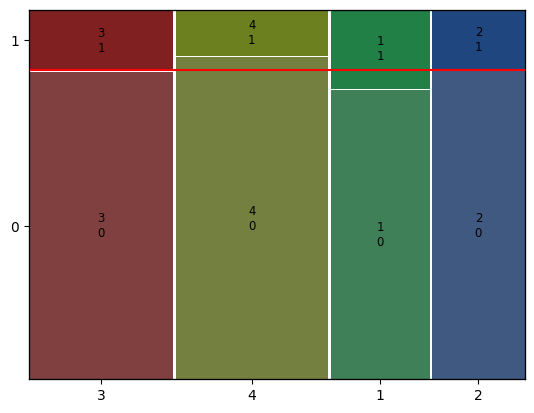

Attrition               0         1
JobSatisfaction                    
1                0.786008  0.213992
2                0.836283  0.163717
3                0.833333  0.166667
4                0.873995  0.126005
------------------------------


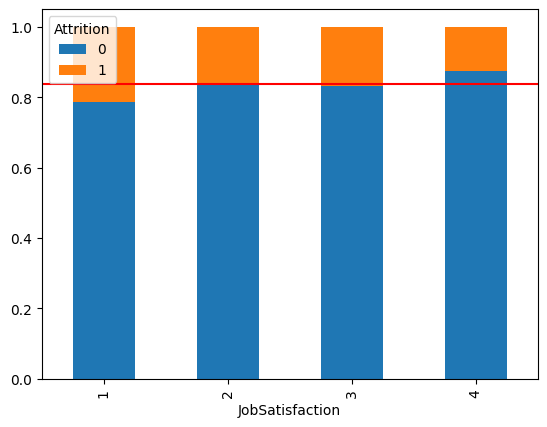

In [16]:
mosaic(df, ['JobSatisfaction', 'Attrition'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-df['Attrition'].mean(), color='r')    # 전체 
plt.show()
                

temp = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-df['Attrition'].mean(), color='r')
plt.show()

3) 수치화 : 카이제곱검정

In [17]:
table = pd.crosstab(df['Attrition'], df['JobSatisfaction'])
display(table)

spst.chi2_contingency(table)

JobSatisfaction,1,2,3,4
Attrition,,,,
0,191,189,295,326
1,52,37,59,47


Chi2ContingencyResult(statistic=np.float64(8.40684948576828), pvalue=np.float64(0.0383107376547955), dof=3, expected_freq=array([[203.38043478, 189.15217391, 296.2826087 , 312.18478261],
       [ 39.61956522,  36.84782609,  57.7173913 ,  60.81521739]]))

4) 파악된 내용을 기술해 봅시다.

- 귀무가설을 기각한다
- 두 변수는 서로 독립이라고 보기 어렵다
- 즉, 두 변수 사이에 유의한 관련성이 있다

## 2.3. MaritalStatus --> Attrition

In [19]:
pd.crosstab(df['Attrition'], df['MaritalStatus'])

MaritalStatus,Divorced,Married,Single
Attrition,,,
0,241,479,281
1,23,69,103


1) 교차표

In [20]:
pd.crosstab(df['Attrition'], df['MaritalStatus'], normalize = 'all')

MaritalStatus,Divorced,Married,Single
Attrition,,,
0,0.201505,0.400502,0.23495
1,0.019231,0.057692,0.08612


2) 시각화

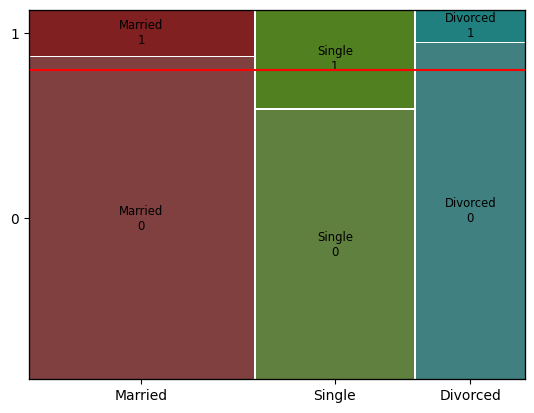

Attrition             0         1
MaritalStatus                    
Divorced       0.912879  0.087121
Married        0.874088  0.125912
Single         0.731771  0.268229
------------------------------


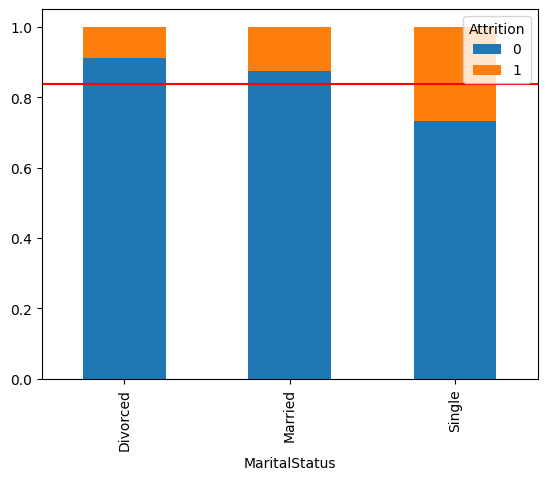

In [21]:
mosaic(df, ['MaritalStatus', 'Attrition'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-df['Attrition'].mean(), color='r')    # 전체 
plt.show()
                

temp = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-df['Attrition'].mean(), color='r')
plt.show()

3) 수치화 : 카이제곱검정

In [22]:
table = pd.crosstab(df['Attrition'], df['MaritalStatus'])
display(table)

spst.chi2_contingency(table)

MaritalStatus,Divorced,Married,Single
Attrition,,,
0,241,479,281
1,23,69,103


Chi2ContingencyResult(statistic=np.float64(47.82247929575401), pvalue=np.float64(4.1255377505408196e-11), dof=2, expected_freq=array([[220.95652174, 458.65217391, 321.39130435],
       [ 43.04347826,  89.34782609,  62.60869565]]))

4) 파악된 내용을 기술해 봅시다.

- 귀무가설을 강하게 기각
- 두 변수 사이에 통계적으로 매우 유의한 관계가 있다

In [53]:
# 이혼, 결혼
df1 = df.copy()
df1 = df1[(df1['MaritalStatus']=='Married') | (df1['MaritalStatus']=='Divorced')]
temp = pd.crosstab(df1['MaritalStatus'], df1[target], normalize='index')
temp

NameError: name 'target' is not defined

## 2.4. OverTime --> Attrition

In [23]:
pd.crosstab(df['Attrition'], df['OverTime'])

OverTime,No,Yes
Attrition,,
0,764,237
1,90,105


1) 교차표

In [24]:
pd.crosstab(df['Attrition'], df['OverTime'], normalize = 'all')

OverTime,No,Yes
Attrition,,
0,0.638796,0.198161
1,0.075251,0.087793


2) 시각화

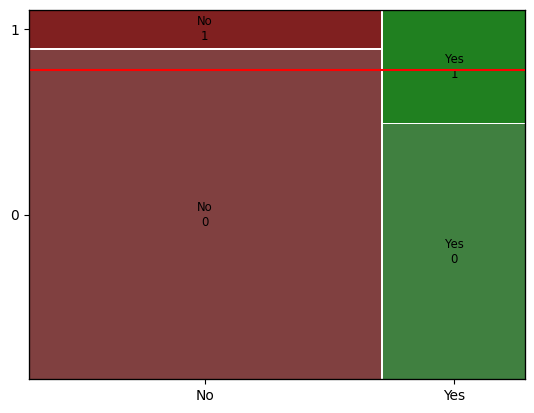

Attrition         0         1
OverTime                     
No         0.894614  0.105386
Yes        0.692982  0.307018
------------------------------


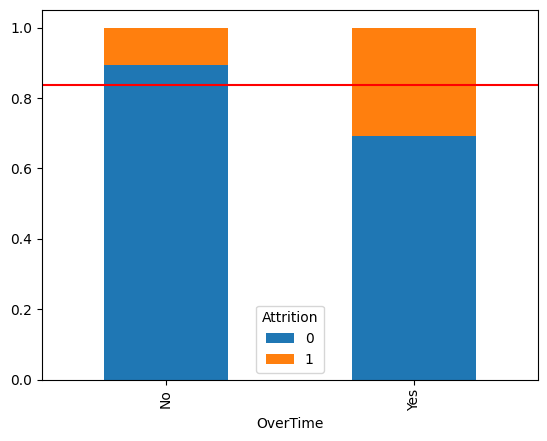

In [25]:
mosaic(df, ['OverTime', 'Attrition'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-df['Attrition'].mean(), color='r')    # 전체 
plt.show()
                

temp = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-df['Attrition'].mean(), color='r')
plt.show()

3) 수치화 : 카이제곱검정

In [26]:
table = pd.crosstab(df['Attrition'], df['OverTime'])
display(table)

spst.chi2_contingency(table)

OverTime,No,Yes
Attrition,,
0,764,237
1,90,105


Chi2ContingencyResult(statistic=np.float64(71.28471646317081), pvalue=np.float64(3.0922183158961214e-17), dof=1, expected_freq=array([[714.76086957, 286.23913043],
       [139.23913043,  55.76086957]]))

4) 파악된 내용을 기술해 봅시다.

- 귀무가설을 강하게 기각
- 두 변수 사이에 통계적으로 매우 유의한 관련성이 있다

# 3.숫자-->범주

## 3.1. Age --> Attrition

1) 시각화

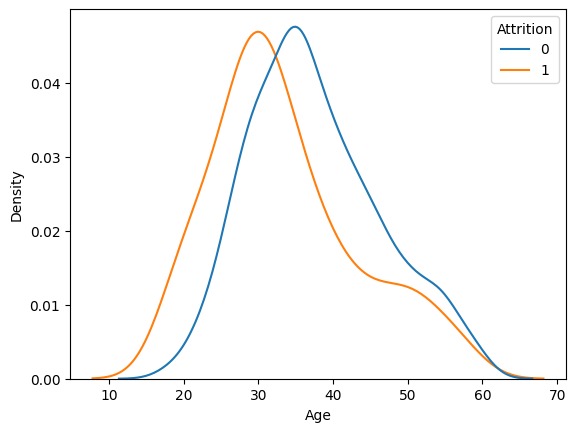

In [50]:
sns.kdeplot(x='Age', data=df, hue='Attrition', common_norm = False)
plt.show()

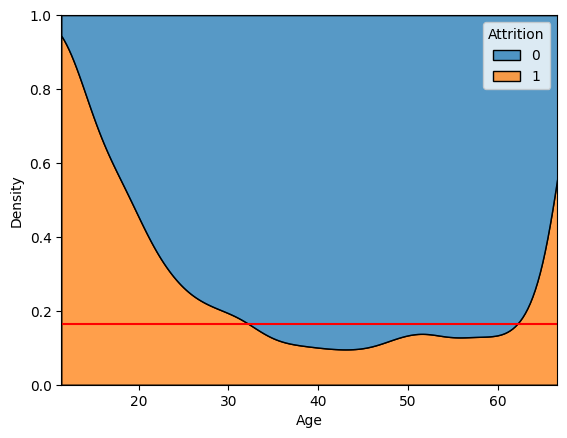

In [30]:
sns.kdeplot(x='Age', data=df, hue='Attrition', multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

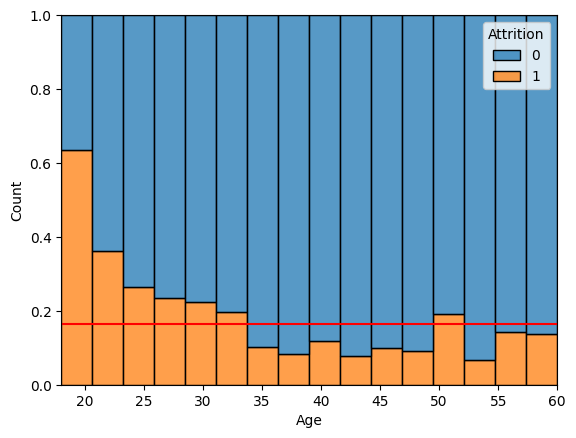

In [31]:
sns.histplot(x='Age', data=df, hue='Attrition', bins=16, multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

- 이직자(Attrition=1)는 비교적 젊은 층에 더 많이 분포하고
- 비이직자(Attrition=0)는 조금 더 높은 연령대에 많이 분포합니다.

## 3.2. DistanceFromHome --> Attrition

1) 시각화

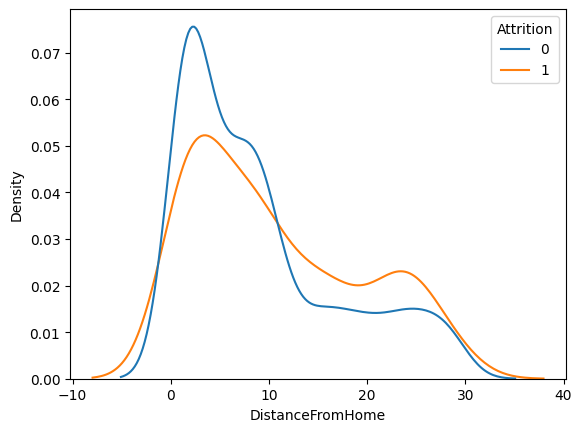

In [37]:
sns.kdeplot(x='DistanceFromHome', data=df, hue='Attrition', common_norm = False)
plt.show()

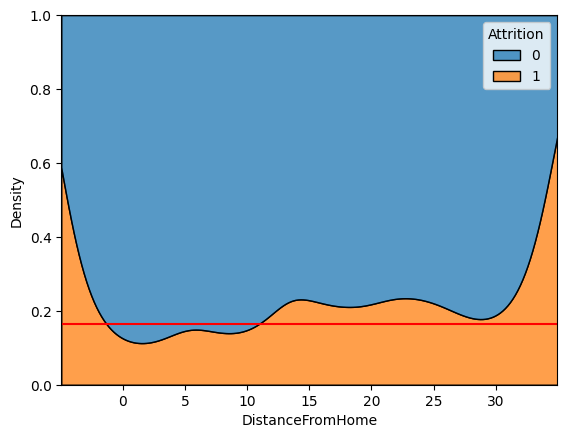

In [38]:
sns.kdeplot(x='DistanceFromHome', data=df, hue='Attrition', multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

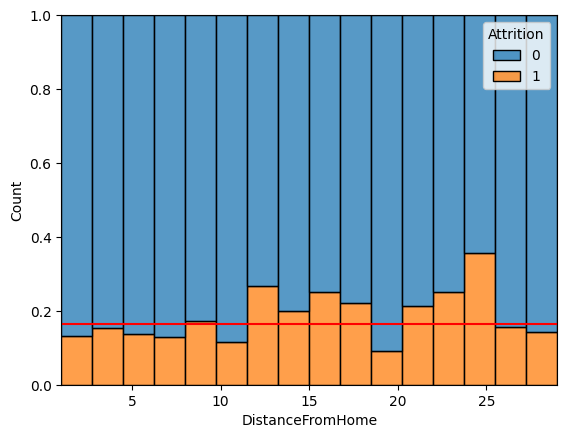

In [39]:
sns.histplot(x='DistanceFromHome', data=df, hue='Attrition', bins=16, multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

- 출퇴근 거리에 따라 이직 여부 분포가 달라 보이고
- 따라서 DistanceFromHome과 Attrition은 독립 관계보다는 관련이 있는 관계로 보입니다

## 3.3. MonthlyIncome --> Attrition

1) 시각화

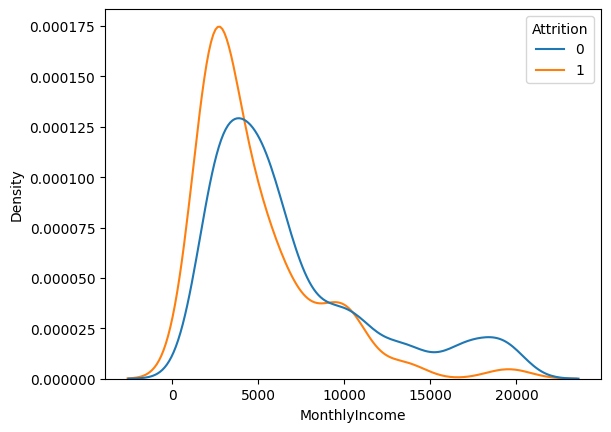

In [40]:
sns.kdeplot(x='MonthlyIncome', data=df, hue='Attrition', common_norm = False)
plt.show()

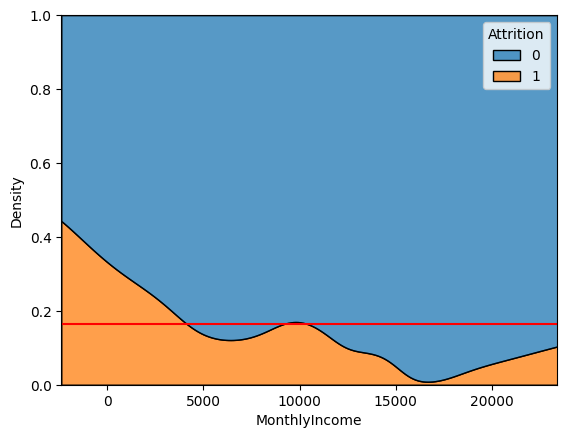

In [41]:
sns.kdeplot(x='MonthlyIncome', data=df, hue='Attrition', multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

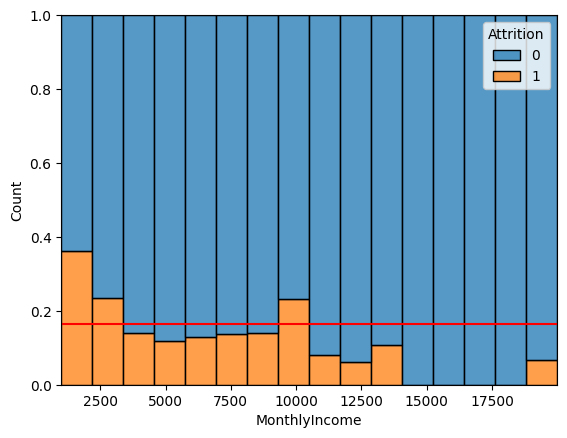

In [42]:
sns.histplot(x='MonthlyIncome', data=df, hue='Attrition', bins=16, multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

- 월소득 수준에 따라 이직 여부 분포가 달라 보이므로
- MonthlyIncome과 Attrition은 완전히 독립 관계는 아닌 것처럼 보인다

## 3.4. PercentSalaryHike --> Attrition

1) 시각화

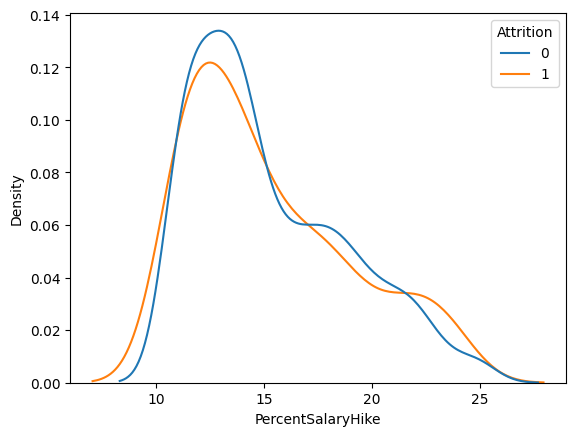

In [43]:
sns.kdeplot(x='PercentSalaryHike', data=df, hue='Attrition', common_norm = False)
plt.show()

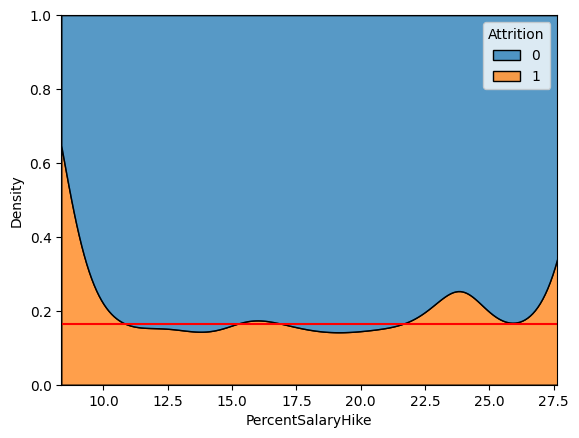

In [44]:
sns.kdeplot(x='PercentSalaryHike', data=df, hue='Attrition', multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

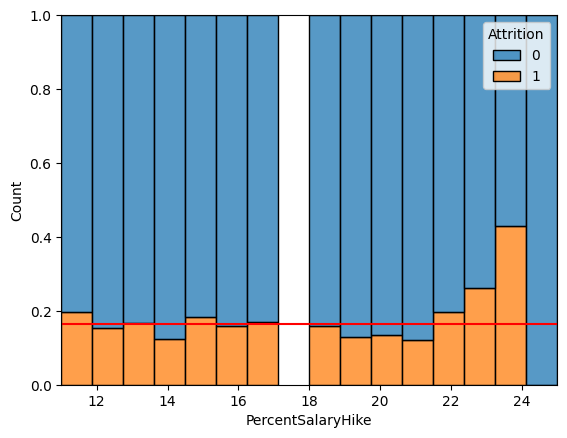

In [45]:
sns.histplot(x='PercentSalaryHike', data=df, hue='Attrition', bins=16, multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

- PercentSalaryHike는 Attrition과 아주 강한 차이를 보이진 않으며
- 시각적으로는 약한 수준의 관련성만 관찰된다.

## 3.5. TotalWorkingYears --> Attrition

1) 시각화

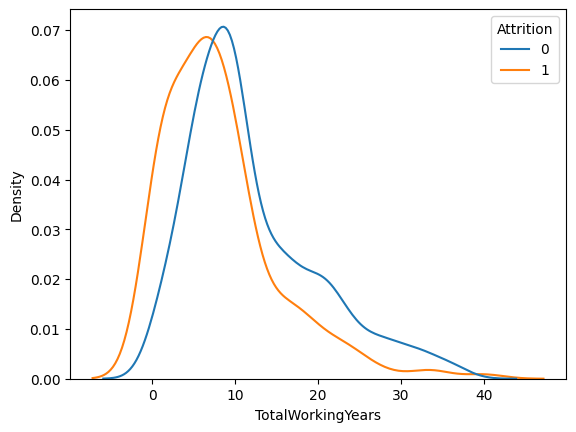

In [46]:
sns.kdeplot(x='TotalWorkingYears', data=df, hue='Attrition', common_norm = False)
plt.show()

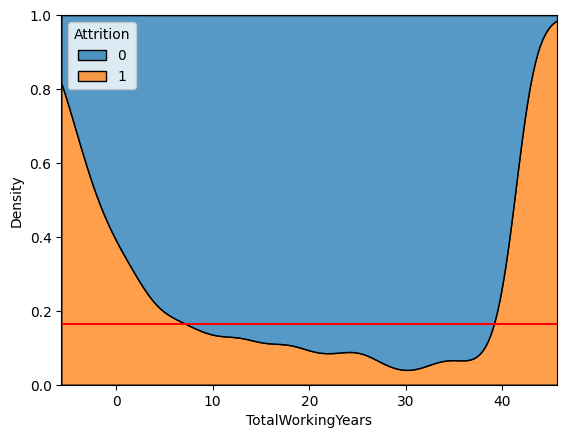

In [47]:
sns.kdeplot(x='TotalWorkingYears', data=df, hue='Attrition', multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

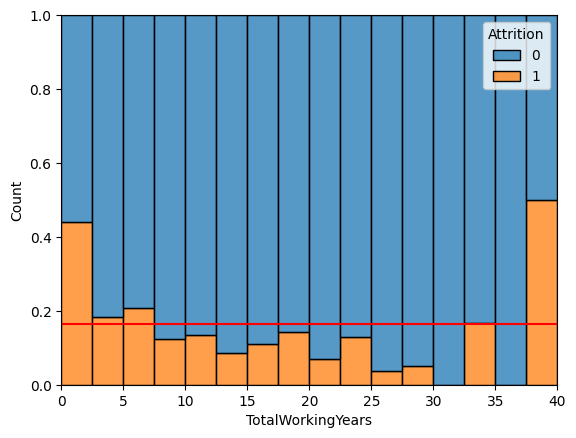

In [48]:
sns.histplot(x='TotalWorkingYears', data=df, hue='Attrition', bins=16, multiple='fill')

plt.axhline(df['Attrition'].mean(), color='r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

- 총 근무연수가 짧을수록 이직 가능성이 높고
- 길수록 잔류 가능성이 높아 보인다.

# 4.관계 정리하기

- Attrition에 영향을 주는 주요 변수는
1. OverTime
2. MaritalStatus
3. JobSatisfaction이

연속형 변수 중에서는
1. Age
2. MonthlyIncome
3. DistanceFromHome
4. TotalWorkingYears가 이직과 관련된 경향을 보였다.

따라서 이직률을 낮추기 위해서는 야근 관리, 직무 만족도 개선, 초기 경력자와 저소득 직원에 대한 유지 전략이 중요하다고 해석할 수 있다.

# 관계없음

- Gender
- PercentSalaryHike